# Titanic Feature Engineering

This notebook focuses on creating new features from the original dataset.

The goals of this notebook are:
- create family-based features
- identify passengers traveling alone
- extract title information from passenger names
- analyze how these engineered features relate to survival

In [1]:
import sys
import os

sys.path.append(os.path.abspath(".."))

In [2]:
from src.load_data import load_data
from src.features import add_family_size, add_is_alone, add_title, engineer_features
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df = load_data()
df.head()

,passengerid,survived,pclass,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Family Size Feature

We create a new feature called `family_size` using:
- `sibsp`
- `parch`

Formula:

`family_size = sibsp + parch + 1`

The `+1` includes the passenger.

In [12]:
df = add_family_size(df)
df[["sibsp", "parch", "family_size"]].head()

,sibsp,parch,family_size
0,1,0,2
1,1,0,2
2,0,0,1
3,1,0,2
4,0,0,1


## Survival by Family Size

This plot shows how survival changes across different family sizes.

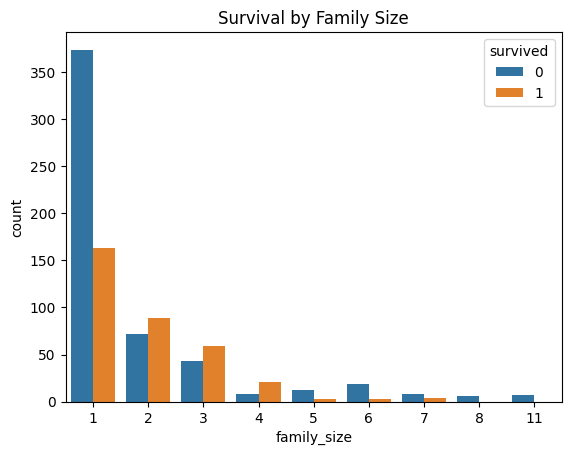

In [5]:
sns.countplot(data=df, x="family_size", hue="survived")
plt.title("Survival by Family Size")
plt.show()

## Is Alone Feature

We create another feature called `is_alone`.

- 1 means the passenger traveled alone
- 0 means the passenger traveled with family

In [13]:
df = add_is_alone(df)
df[["family_size", "is_alone"]].head()

,family_size,is_alone
0,2,0
1,2,0
2,1,1
3,2,0
4,1,1


## Survival by Being Alone

This plot compares the survival distribution of passengers traveling alone versus those traveling with family.

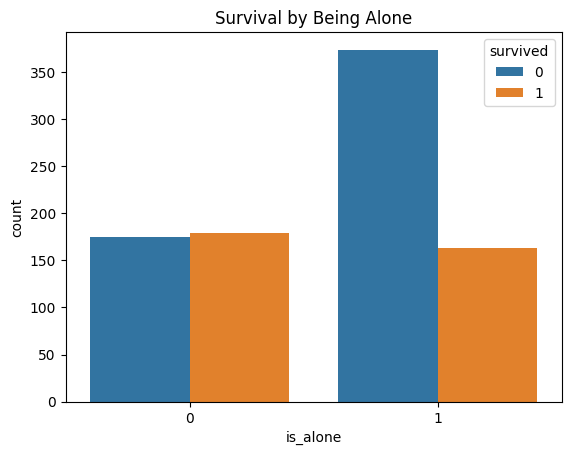

In [7]:
sns.countplot(data=df, x="is_alone", hue="survived")
plt.title("Survival by Being Alone")
plt.show()

## Title Extraction

Passenger titles such as `Mr`, `Mrs`, `Miss`, and `Master` can provide useful information about gender, age, and social status.

We extract the title from the `name` column.

In [14]:
df = add_title(df)
df[["name", "title"]].head()

,name,title
0,"Braund, Mr. Owen Harris",Mr
1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",Mrs
2,"Heikkinen, Miss. Laina",Miss
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",Mrs
4,"Allen, Mr. William Henry",Mr


In [15]:
df.columns

Index(['passengerid', 'survived', 'pclass', 'name', 'sex', 'age', 'sibsp',
       'parch', 'ticket', 'fare', 'cabin', 'embarked', 'family_size',
       'is_alone', 'title'],
      dtype='str')

## Title Frequency

This step shows how many passengers belong to each title category.

In [9]:
df["title"].value_counts()

title
Mr          517
Miss        182
Mrs         125
Master       40
Dr            7
Rev           6
Major         2
Mlle          2
Col           2
Don           1
Mme           1
Ms            1
Lady          1
Sir           1
Capt          1
Countess      1
Jonkheer      1
Name: count, dtype: int64

## Group Rare Titles

Rare titles are grouped into a single category called `Rare` to simplify the analysis.

In [10]:
df["title"] = df["title"].replace(
    ["Lady", "Countess", "Capt", "Col", "Don", "Dr", "Major", "Rev", "Sir", "Jonkheer", "Dona"],
    "Rare"
)

## Survival by Title

This plot compares survival across passenger titles.

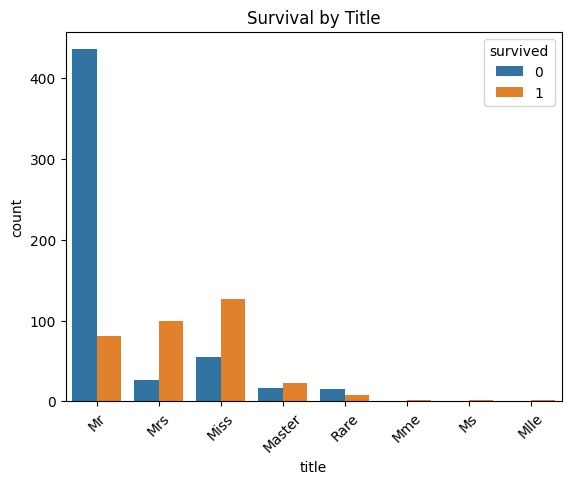

In [11]:
sns.countplot(data=df, x="title", hue="survived")
plt.title("Survival by Title")
plt.xticks(rotation=45)
plt.show()

## Feature Engineering Summary

The engineered features created in this notebook are:
- `family_size`
- `is_alone`
- `title`

These new features may improve the predictive performance of machine learning models.